# Tree-Based Algorithms and Ensemble Methods

Notebook ini membahas **tree-based algorithms** dan **ensemble methods**, yaitu kelompok model machine learning yang berbasis pada proses pemisahan data secara bertahap. Fokus utama chapter ini adalah Decision Tree, Random Forest, Gradient Boosting, hyperparameter tuning, feature importance, dan perbandingan beberapa metode ensemble.

Notebook disusun dalam Bahasa Indonesia dengan penjelasan teori, rumus matematis dalam format Markdown/LaTeX yang benar, contoh kode, visualisasi, interpretasi hasil, serta evaluasi model.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami cara kerja Decision Tree untuk klasifikasi.
- Menjelaskan node, branch, leaf node, root node, impurity, dan split.
- Menggunakan Gini impurity dan entropy sebagai kriteria pemisahan.
- Mengimplementasikan Decision Tree dengan scikit-learn.
- Memvisualisasikan struktur pohon keputusan.
- Memahami konsep bagging dan Random Forest.
- Menjelaskan feature importance pada Random Forest.
- Memahami konsep boosting dan Gradient Boosting Machine.
- Melakukan hyperparameter tuning untuk model berbasis pohon.
- Membandingkan Decision Tree, Random Forest, Gradient Boosting, dan Stacking Classifier.

## Persiapan Library

Cell berikut memuat library yang digunakan pada notebook ini. Warning diabaikan agar output notebook tetap bersih dan tidak mengganggu tampilan hasil.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, validation_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Tree-based algorithms adalah model yang mengambil keputusan dengan membagi data berdasarkan nilai fitur. Proses pembagian ini dilakukan secara rekursif hingga model membentuk struktur seperti pohon.

Decision Tree mudah dipahami karena alur keputusannya dapat divisualisasikan. Namun, decision tree tunggal sering rentan terhadap overfitting. Untuk mengatasi kelemahan tersebut, model berbasis pohon sering digabungkan dalam ensemble, seperti Random Forest dan Gradient Boosting.

Topik utama chapter ini:

| Topik | Inti Pembahasan |
|---|---|
| Decision Tree | Model pohon keputusan berbasis split fitur |
| Gini Impurity | Ukuran ketidakmurnian node |
| Entropy | Ukuran ketidakpastian informasi |
| Random Forest | Ensemble banyak decision tree dengan bagging |
| Bagging | Melatih model pada sampel bootstrap |
| Feature Importance | Mengukur kontribusi fitur terhadap keputusan model |
| Gradient Boosting | Ensemble berurutan yang memperbaiki error model sebelumnya |
| Grid Search | Tuning hyperparameter secara sistematis |
| Stacking | Menggabungkan beberapa model dengan meta-model |

## Introduction to Decision Trees

Decision Tree adalah algoritma yang menggunakan struktur pohon untuk membuat prediksi. Model ini bekerja dengan membagi data berdasarkan fitur tertentu. Setiap pembagian disebut **split**, setiap titik keputusan disebut **node**, dan hasil akhir prediksi berada pada **leaf node**.

Konsep utama pada Decision Tree:

- **Root node**: node awal yang berisi seluruh data training.
- **Internal node**: node yang masih memiliki split.
- **Branch**: cabang hasil keputusan dari suatu split.
- **Leaf node**: node akhir yang menghasilkan prediksi.
- **Impurity**: ukuran seberapa campur kelas pada suatu node.
- **Split criterion**: aturan untuk memilih fitur dan threshold terbaik.

Decision Tree populer karena mudah diinterpretasikan dan dapat digunakan untuk klasifikasi maupun regresi.

## Rumus Gini Impurity

Gini impurity mengukur seberapa tidak murni suatu node. Jika semua data pada node berasal dari satu kelas, maka Gini impurity bernilai 0.

$$
Gini = 1 - \sum_{k=1}^{K} p_k^2
$$

Keterangan:

- $K$ = jumlah kelas
- $p_k$ = proporsi data kelas ke-$k$ pada node

Interpretasi:

- $Gini = 0$ berarti node sangat murni.
- Semakin besar Gini, semakin campur kelas pada node tersebut.
- Decision tree memilih split yang menurunkan impurity paling besar.

## Rumus Entropy

Entropy juga digunakan untuk mengukur ketidakpastian atau impurity pada node.

$$
Entropy = - \sum_{k=1}^{K} p_k \log_2(p_k)
$$

Keterangan:

- $K$ = jumlah kelas
- $p_k$ = proporsi data kelas ke-$k$ pada node

Entropy bernilai rendah jika node didominasi satu kelas, dan bernilai tinggi jika kelas tercampur merata.

## Rumus Information Gain

Information gain mengukur seberapa besar penurunan impurity setelah split dilakukan.

$$
IG = I(parent) - \sum_{j=1}^{m} \frac{N_j}{N} I(child_j)
$$

Keterangan:

- $IG$ = information gain
- $I(parent)$ = impurity node sebelum split
- $I(child_j)$ = impurity child node ke-$j$
- $N_j$ = jumlah sampel pada child node ke-$j$
- $N$ = jumlah sampel pada parent node
- $m$ = jumlah child node

Split terbaik adalah split yang menghasilkan information gain paling besar.

## Load Dataset Iris

Dataset Iris digunakan sebagai contoh utama. Dataset ini memiliki 150 data, 4 fitur numerik, dan 3 kelas bunga.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Shape dataset:", df_iris.shape)
print("Target names:", iris.target_names)
df_iris.head()

Shape dataset: (150, 6)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Train-Test Split

Data dibagi menjadi training set dan test set. Parameter `stratify=y` digunakan agar proporsi kelas tetap seimbang.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2024,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 105
Jumlah data testing: 45


## Implementasi Decision Tree

Model pertama yang digunakan adalah `DecisionTreeClassifier`. Pada tahap awal, model dibuat dengan pengaturan sederhana agar perilaku dasar decision tree dapat diamati.

In [4]:
dt_clf = DecisionTreeClassifier(random_state=2024)

dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.3f}")

dt_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

dt_report

Decision Tree Accuracy: 0.911


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.866667,0.866667,0.866667,15.000000
virginica,0.866667,0.866667,0.866667,15.000000
accuracy,0.911111,0.911111,0.911111,0.911111
macro avg,0.911111,0.911111,0.911111,45.000000
weighted avg,0.911111,0.911111,0.911111,45.000000


## Analisis Decision Tree

Decision Tree dapat menghasilkan performa yang cukup baik pada dataset sederhana seperti Iris. Namun, model pohon tunggal sangat mudah mengikuti pola detail pada data training. Jika tidak dikontrol, pohon dapat tumbuh terlalu dalam dan menyebabkan overfitting.

Overfitting pada decision tree biasanya terjadi ketika:

- `max_depth` terlalu besar atau tidak dibatasi.
- `min_samples_leaf` terlalu kecil.
- Dataset memiliki noise.
- Pohon terlalu banyak membuat split sampai training data hampir dihafal.

## Visualisasi Struktur Decision Tree

Salah satu keunggulan decision tree adalah struktur keputusannya dapat divisualisasikan. Visualisasi ini membantu melihat fitur apa yang digunakan untuk split dan bagaimana model mencapai prediksi.

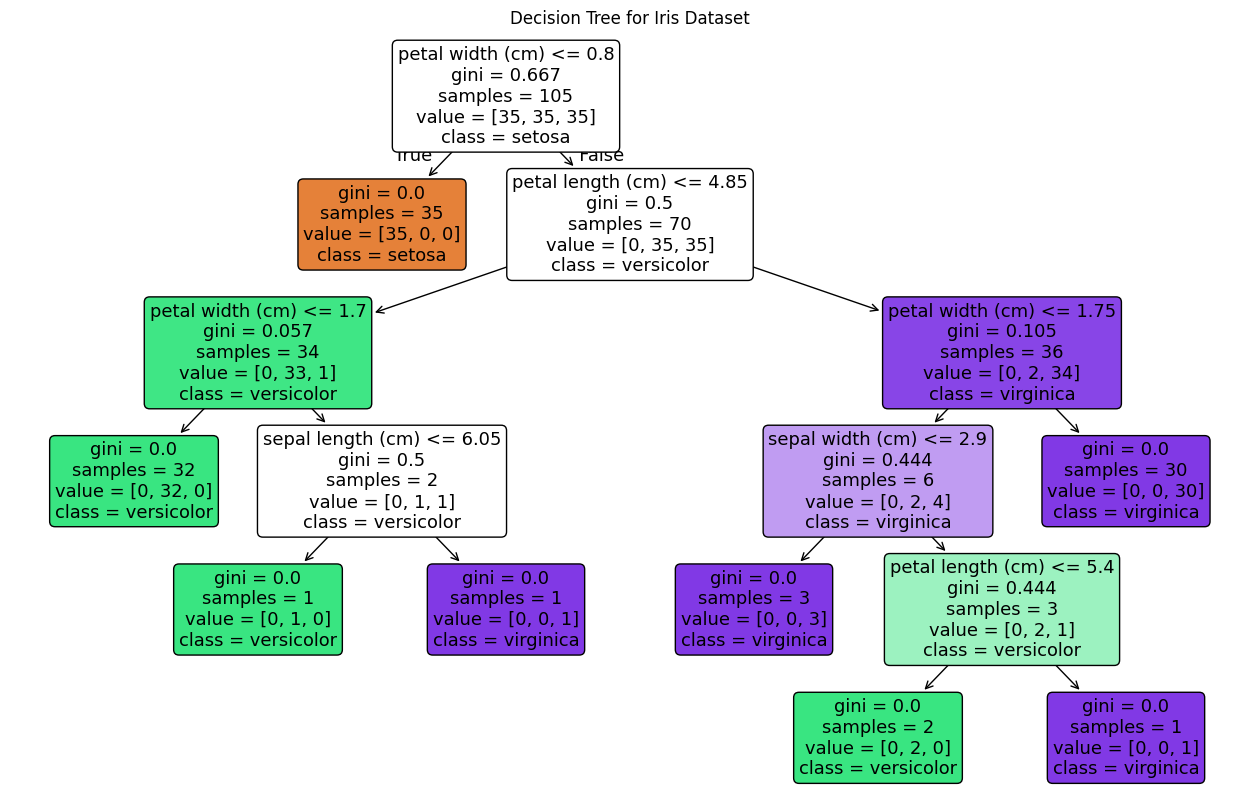

In [5]:
plt.figure(figsize=(16, 10))
plot_tree(
    dt_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Iris Dataset")
plt.show()

## Interpretasi Visualisasi Decision Tree

Setiap node pada visualisasi pohon biasanya memuat beberapa informasi:

| Informasi | Penjelasan |
|---|---|
| Feature condition | Aturan split, misalnya `petal width <= 0.8` |
| Gini | Tingkat impurity pada node |
| Samples | Jumlah data yang masuk ke node |
| Value | Jumlah data dari setiap kelas |
| Class | Prediksi kelas mayoritas pada node |

Jika sebuah node tidak memiliki cabang lanjutan, node tersebut disebut leaf node. Prediksi diberikan berdasarkan kelas mayoritas pada leaf node tersebut.

## Hyperparameter Penting pada Decision Tree

Decision Tree dapat dikontrol dengan beberapa hyperparameter agar tidak terlalu kompleks.

| Hyperparameter | Fungsi |
|---|---|
| `max_depth` | Membatasi kedalaman maksimum pohon |
| `min_samples_split` | Minimum sampel agar node boleh di-split |
| `min_samples_leaf` | Minimum sampel pada leaf node |
| `max_features` | Jumlah maksimum fitur yang dipertimbangkan saat split |
| `criterion` | Ukuran impurity, misalnya `gini` atau `entropy` |

Pengaturan hyperparameter ini penting untuk mengurangi overfitting.

## Pengaruh Max Depth terhadap Performa Decision Tree

Contoh berikut membandingkan performa decision tree dengan beberapa nilai `max_depth`.

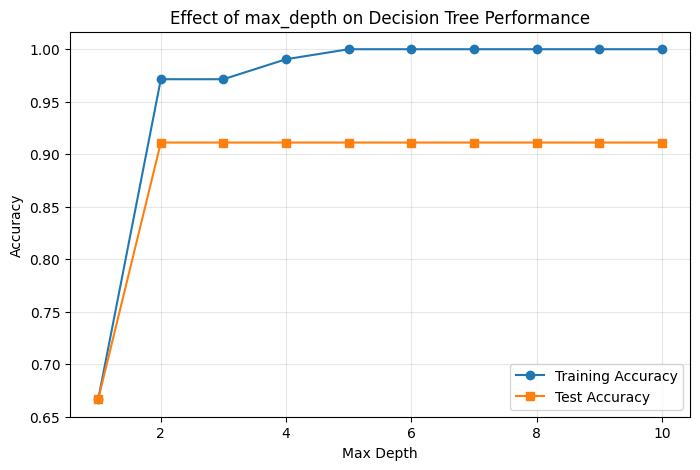

,max_depth,train_accuracy,test_accuracy
0,1,0.666667,0.666667
1,2,0.971429,0.911111
2,3,0.971429,0.911111
3,4,0.990476,0.911111
4,5,1.000000,0.911111
5,6,1.000000,0.911111
6,7,1.000000,0.911111
7,8,1.000000,0.911111
8,9,1.000000,0.911111
9,10,1.000000,0.911111


In [6]:
depth_values = range(1, 11)

train_scores = []
test_scores = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=2024)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depth_values, train_scores, marker="o", label="Training Accuracy")
plt.plot(depth_values, test_scores, marker="s", label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Decision Tree Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "max_depth": list(depth_values),
    "train_accuracy": train_scores,
    "test_accuracy": test_scores
})

## Analisis Max Depth

Ketika `max_depth` kecil, model cenderung sederhana dan dapat mengalami underfitting. Ketika `max_depth` terlalu besar, model dapat menghafal data training dan mengalami overfitting.

Nilai terbaik biasanya dipilih menggunakan cross-validation, bukan hanya berdasarkan satu test split.

## Random Forests and Bagging

Random Forest adalah ensemble yang menggabungkan banyak decision tree. Setiap pohon dilatih pada sampel bootstrap, yaitu sampel yang diambil dari data training dengan pengembalian. Selain itu, pada setiap split, hanya sebagian fitur yang dipertimbangkan.

Tujuan Random Forest adalah mengurangi variance dari decision tree tunggal. Jika satu decision tree mudah overfitting, kumpulan banyak tree dapat menghasilkan prediksi yang lebih stabil.

Konsep utama:

- **Bagging**: melatih banyak model pada sampel bootstrap.
- **Bootstrap sample**: sampel data dengan replacement.
- **Majority vote**: prediksi klasifikasi berdasarkan suara terbanyak.
- **Feature randomness**: setiap split hanya mempertimbangkan subset fitur.

## Rumus Majority Voting

Untuk klasifikasi, Random Forest menggunakan voting mayoritas dari banyak tree.

$$
\hat{y} = \arg\max_c \sum_{t=1}^{T} I(h_t(x)=c)
$$

Keterangan:

- $\hat{y}$ = kelas prediksi akhir
- $c$ = kandidat kelas
- $T$ = jumlah tree
- $h_t(x)$ = prediksi dari tree ke-$t$
- $I$ = fungsi indikator

Kelas dengan jumlah suara terbanyak menjadi prediksi final.

## Rumus Prediksi Rata-Rata untuk Regresi

Untuk regresi, ensemble tree biasanya menggunakan rata-rata prediksi semua tree.

$$
\hat{y} = \frac{1}{T}\sum_{t=1}^{T} h_t(x)
$$

Keterangan:

- $T$ = jumlah tree
- $h_t(x)$ = prediksi tree ke-$t$

Averaging membantu mengurangi variance dan membuat prediksi lebih stabil.

## Implementasi Random Forest

Random Forest diterapkan pada dataset Iris menggunakan 100 estimator.

In [7]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=2024
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.3f}")

rf_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

rf_report

Random Forest Accuracy: 0.933


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.875000,0.933333,0.903226,15.000000
virginica,0.928571,0.866667,0.896552,15.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.934524,0.933333,0.933259,45.000000
weighted avg,0.934524,0.933333,0.933259,45.000000


## Analisis Random Forest

Random Forest biasanya lebih stabil dibanding decision tree tunggal karena menggabungkan banyak tree. Jika satu tree membuat prediksi yang terlalu spesifik terhadap data training, tree lain dapat membantu menyeimbangkan prediksi.

Namun, Random Forest lebih sulit diinterpretasikan dibanding decision tree tunggal karena terdiri dari banyak pohon.

## Feature Importance pada Random Forest

Random Forest menyediakan nilai feature importance yang menunjukkan fitur mana yang paling sering membantu mengurangi impurity dalam split.

Nilai importance yang tinggi berarti fitur tersebut banyak berkontribusi terhadap keputusan model.

In [8]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_importance_df = pd.DataFrame({
    "feature": np.array(iris.feature_names)[indices],
    "importance": importances[indices]
})

feature_importance_df

,feature,importance
0,petal length (cm),0.468162
1,petal width (cm),0.422612
2,sepal length (cm),0.086300
3,sepal width (cm),0.022926


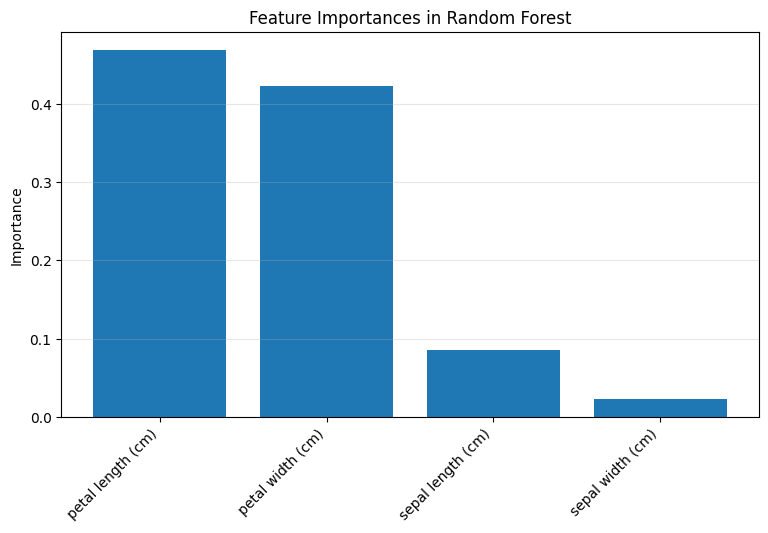

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Analisis Feature Importance

Pada Iris dataset, fitur petal biasanya lebih penting dibanding sepal karena lebih membantu membedakan spesies. Feature importance dapat digunakan untuk interpretasi model atau sebagai langkah awal feature selection.

Namun, feature importance pada tree-based model perlu ditafsirkan dengan hati-hati, terutama jika fitur saling berkorelasi.

## Bagging Classifier

Bagging tidak hanya dapat digunakan pada Random Forest. Scikit-learn menyediakan `BaggingClassifier` yang dapat digunakan untuk membungkus model lain, misalnya Decision Tree.

In [10]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=2024),
    n_estimators=100,
    random_state=2024
)

bagging_clf.fit(X_train, y_train)

y_pred_bagging = bagging_clf.predict(X_test)

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

print(f"Bagging Classifier Accuracy: {bagging_accuracy:.3f}")

Bagging Classifier Accuracy: 0.933


## Gradient Boosting Machines

Gradient Boosting Machine atau GBM adalah ensemble yang membangun tree secara berurutan. Berbeda dari Random Forest yang melatih banyak tree secara relatif paralel, Gradient Boosting melatih tree satu per satu.

Setiap tree baru berusaha memperbaiki kesalahan dari model sebelumnya. Karena itu, boosting sering kuat untuk meningkatkan performa, tetapi juga berisiko overfitting jika jumlah estimator terlalu besar atau learning rate tidak sesuai.

Perbandingan sederhana:

| Metode | Cara Kerja | Tujuan Utama |
|---|---|---|
| Bagging | Banyak model dilatih pada bootstrap sample | Mengurangi variance |
| Boosting | Model dilatih berurutan untuk memperbaiki error | Mengurangi bias |
| Stacking | Beberapa model digabung dengan meta-model | Menggabungkan kekuatan model berbeda |

## Rumus Additive Model pada Gradient Boosting

Gradient Boosting membangun model sebagai penjumlahan model-model lemah.

$$
F_M(x) = F_0(x) + \sum_{m=1}^{M} \nu h_m(x)
$$

Keterangan:

- $F_M(x)$ = model akhir setelah $M$ iterasi
- $F_0(x)$ = model awal
- $h_m(x)$ = weak learner ke-$m$
- $\nu$ = learning rate
- $M$ = jumlah estimator

Learning rate mengontrol seberapa besar kontribusi setiap tree baru terhadap model akhir.

## Rumus Residual pada Boosting

Untuk regresi, tree baru biasanya dilatih untuk memprediksi residual dari model sebelumnya.

$$
r_i = y_i - F_{m-1}(x_i)
$$

Keterangan:

- $r_i$ = residual data ke-$i$
- $y_i$ = nilai aktual
- $F_{m-1}(x_i)$ = prediksi model sebelumnya

Intuisi boosting adalah memperbaiki error secara bertahap.

## Implementasi Gradient Boosting Classifier

Gradient Boosting diterapkan pada dataset Iris.

In [11]:
gbm_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=2024
)

gbm_clf.fit(X_train, y_train)

y_pred_gbm = gbm_clf.predict(X_test)

gbm_accuracy = accuracy_score(y_test, y_pred_gbm)

print(f"Gradient Boosting Accuracy: {gbm_accuracy:.3f}")

gbm_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_gbm,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

gbm_report

Gradient Boosting Accuracy: 0.956


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.933333,0.933333,0.933333,15.000000
virginica,0.933333,0.933333,0.933333,15.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.955556,0.955556,0.955556,45.000000
weighted avg,0.955556,0.955556,0.955556,45.000000


## Analisis Gradient Boosting

Gradient Boosting dapat menghasilkan performa tinggi karena model belajar secara bertahap dari kesalahan sebelumnya. Namun, boosting lebih sensitif terhadap hyperparameter seperti `learning_rate`, `n_estimators`, dan `max_depth`.

Jika learning rate terlalu besar atau jumlah estimator terlalu banyak, model dapat overfitting.

## Validation Curve untuk Learning Rate

Validation curve membantu melihat pengaruh perubahan hyperparameter terhadap training score dan validation score.

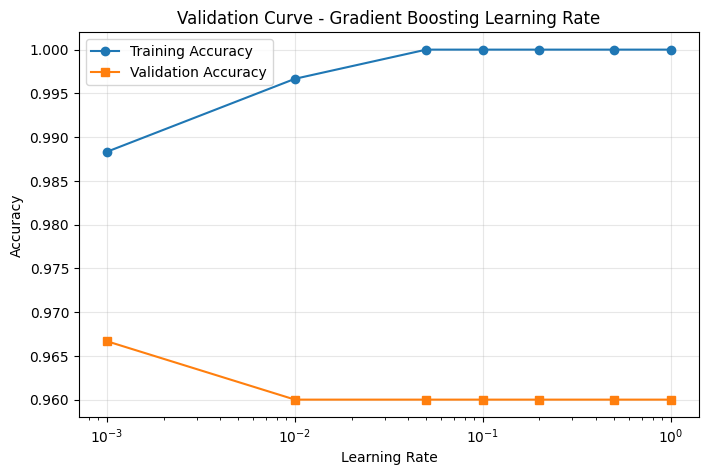

,learning_rate,train_accuracy,validation_accuracy
0,0.001,0.988333,0.966667
1,0.010,0.996667,0.960000
2,0.050,1.000000,0.960000
3,0.100,1.000000,0.960000
4,0.200,1.000000,0.960000
5,0.500,1.000000,0.960000
6,1.000,1.000000,0.960000


In [12]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

train_scores, val_scores = validation_curve(
    GradientBoostingClassifier(n_estimators=100, random_state=2024),
    X,
    y,
    param_name="learning_rate",
    param_range=learning_rates,
    cv=5,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, train_mean, marker="o", label="Training Accuracy")
plt.plot(learning_rates, val_mean, marker="s", label="Validation Accuracy")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Gradient Boosting Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "learning_rate": learning_rates,
    "train_accuracy": train_mean,
    "validation_accuracy": val_mean
})

## Early Stopping pada Gradient Boosting

Early stopping adalah strategi untuk menghentikan proses training sebelum model terlalu overfit. Dalam Gradient Boosting, kita dapat menggunakan `n_iter_no_change` dan `validation_fraction`.

Jika validation score tidak membaik setelah beberapa iterasi, training akan dihentikan lebih awal.

In [13]:
gbm_early = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=2024
)

gbm_early.fit(X_train, y_train)

y_pred_early = gbm_early.predict(X_test)

print("Jumlah estimator yang digunakan:", gbm_early.n_estimators_)
print("Accuracy:", accuracy_score(y_test, y_pred_early))

Jumlah estimator yang digunakan: 50
Accuracy: 0.9555555555555556


## Hyperparameter Tuning untuk Trees dan Ensembles

Hyperparameter tuning penting untuk model berbasis pohon karena performanya sangat dipengaruhi oleh kedalaman pohon, jumlah estimator, dan learning rate.

Beberapa hyperparameter penting:

| Model | Hyperparameter |
|---|---|
| Decision Tree | `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion` |
| Random Forest | `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf` |
| Gradient Boosting | `n_estimators`, `learning_rate`, `max_depth`, `subsample` |

## Grid Search pada Gradient Boosting

Contoh berikut menggunakan `GridSearchCV` untuk mencari kombinasi `n_estimators`, `max_depth`, dan `learning_rate` terbaik.

In [14]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

best_gbm = grid_search.best_estimator_
y_pred_best_gbm = best_gbm.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best_gbm):.3f}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 150}
Best CV Accuracy: 0.952
Test Accuracy: 0.933


In [15]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_learning_rate,mean_test_score,std_test_score,rank_test_score
2,150,2,0.01,0.952381,0.000000,1
6,50,4,0.01,0.952381,0.030117,1
5,150,3,0.01,0.952381,0.030117,1
4,100,3,0.01,0.952381,0.030117,1
7,100,4,0.01,0.952381,0.030117,1
10,100,2,0.10,0.952381,0.000000,1
9,50,2,0.10,0.952381,0.000000,1
8,150,4,0.01,0.952381,0.030117,1
12,50,3,0.10,0.952381,0.030117,1
13,100,3,0.10,0.952381,0.030117,1


## Visualisasi Hasil Grid Search

Heatmap berikut memperlihatkan pengaruh kombinasi `max_depth` dan `n_estimators`. Agar visualisasi sederhana, hasil difilter pada learning rate terbaik.

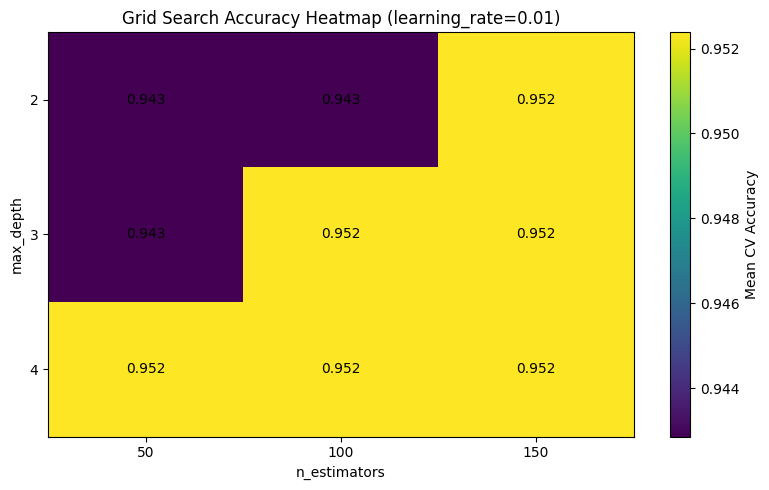

In [16]:
best_lr = grid_search.best_params_["learning_rate"]

results_filtered = grid_results[
    grid_results["param_learning_rate"] == best_lr
].copy()

pivot_table = results_filtered.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators"
)

plt.figure(figsize=(8, 5))
plt.imshow(pivot_table.values, aspect="auto")
plt.colorbar(label="Mean CV Accuracy")
plt.xticks(
    ticks=np.arange(len(pivot_table.columns)),
    labels=pivot_table.columns
)
plt.yticks(
    ticks=np.arange(len(pivot_table.index)),
    labels=pivot_table.index
)
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.title(f"Grid Search Accuracy Heatmap (learning_rate={best_lr})")

for i in range(pivot_table.shape[0]):
    for j in range(pivot_table.shape[1]):
        plt.text(j, i, f"{pivot_table.values[i, j]:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## Randomized Search pada Random Forest

Selain GridSearchCV, kita dapat menggunakan RandomizedSearchCV untuk mencoba kombinasi parameter secara acak. Pendekatan ini lebih efisien jika ruang parameter besar.

In [17]:
from scipy.stats import randint

random_param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 10),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=2024),
    random_param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=2024
)

random_search.fit(X_train, y_train)

best_rf_random = random_search.best_estimator_
y_pred_rf_random = best_rf_random.predict(X_test)

print("Best Random Forest Parameters:", random_search.best_params_)
print(f"Best CV Accuracy: {random_search.best_score_:.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf_random):.3f}")

Best Random Forest Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'n_estimators': 233}
Best CV Accuracy: 0.962
Test Accuracy: 0.956


## Comparing Ensemble Methods

Pada bagian ini, beberapa model dibandingkan:

- Decision Tree
- Bagging Classifier
- Random Forest
- Gradient Boosting
- Stacking Classifier

Tujuannya bukan hanya mencari score tertinggi, tetapi memahami karakteristik masing-masing metode.

## Rumus Stacking secara Konseptual

Stacking menggabungkan prediksi beberapa base model dan menggunakan meta-model untuk membuat prediksi akhir.

Jika terdapat beberapa model dasar:

$$
z = [h_1(x), h_2(x), \ldots, h_T(x)]
$$

Meta-model kemudian mempelajari:

$$
\hat{y} = g(z)
$$

Keterangan:

- $h_t(x)$ = prediksi base model ke-$t$
- $z$ = fitur baru berisi prediksi base models
- $g(z)$ = meta-model
- $\hat{y}$ = prediksi akhir

Stacking mencoba memanfaatkan kekuatan dari beberapa model sekaligus.

In [18]:
rf_stack = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_stack = GradientBoostingClassifier(n_estimators=100, random_state=2024)

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", rf_stack),
        ("gb", gb_stack)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=2024),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=2024),
        n_estimators=100,
        random_state=2024
    ),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=2024),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=2024),
    "Stacking": stacking_clf
}

comparison_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision Macro": precision_score(y_test, pred, average="macro"),
        "Recall Macro": recall_score(y_test, pred, average="macro"),
        "F1 Macro": f1_score(y_test, pred, average="macro")
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("Accuracy", ascending=False)
comparison_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
4,Stacking,0.955556,0.955556,0.955556,0.955556
3,Gradient Boosting,0.955556,0.955556,0.955556,0.955556
2,Random Forest,0.933333,0.934524,0.933333,0.933259
1,Bagging,0.933333,0.934524,0.933333,0.933259
0,Decision Tree,0.911111,0.911111,0.911111,0.911111


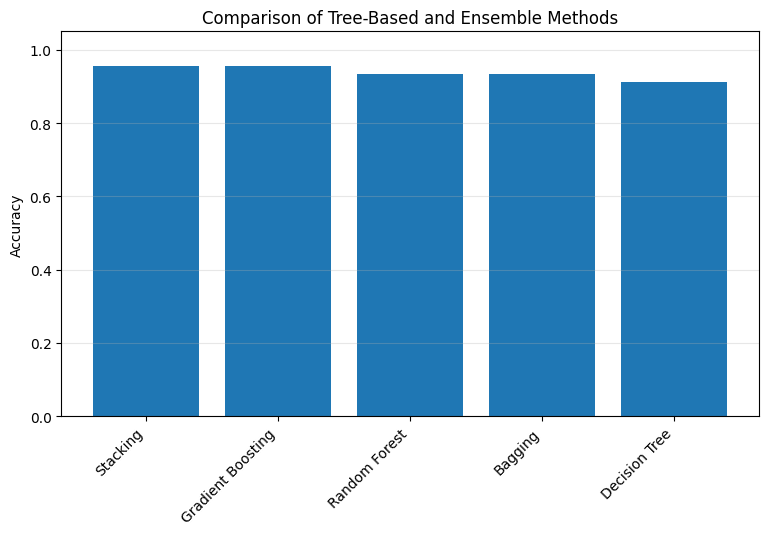

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Comparison of Tree-Based and Ensemble Methods")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Analisis Perbandingan Ensemble

Pada dataset sederhana seperti Iris, perbedaan antar model bisa tidak terlalu besar. Namun, pada dataset nyata yang lebih kompleks, ensemble biasanya lebih stabil dibanding decision tree tunggal.

Interpretasi umum:

- Decision Tree paling mudah diinterpretasikan, tetapi rentan overfitting.
- Bagging mengurangi variance dengan menggabungkan banyak tree.
- Random Forest menambahkan randomness pada fitur sehingga lebih stabil.
- Gradient Boosting membangun model bertahap untuk memperbaiki error.
- Stacking menggabungkan beberapa model dan menggunakan meta-model.

## Studi Kasus Tambahan: Breast Cancer Dataset

Dataset Breast Cancer digunakan untuk melihat performa ensemble pada dataset klasifikasi biner yang lebih realistis.

In [20]:
cancer = load_breast_cancer()

X_cancer = cancer.data
y_cancer = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.3,
    random_state=2024,
    stratify=y_cancer
)

cancer_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=2024),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=2024),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2024)
}

cancer_results = []

for name, model in cancer_models.items():
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    cancer_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred),
        "Recall": recall_score(y_test_c, pred),
        "F1-score": f1_score(y_test_c, pred)
    })

pd.DataFrame(cancer_results).sort_values("F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
2,Gradient Boosting,0.959064,0.971698,0.962617,0.967136
1,Random Forest,0.953216,0.971429,0.953271,0.962264
0,Decision Tree,0.929825,0.952381,0.934579,0.943396


## Feature Importance pada Dataset Breast Cancer

Feature importance membantu melihat fitur mana yang paling berpengaruh dalam model Random Forest.

In [21]:
rf_cancer = cancer_models["Random Forest"]

importances_cancer = rf_cancer.feature_importances_
indices_cancer = np.argsort(importances_cancer)[::-1][:15]

cancer_importance_df = pd.DataFrame({
    "feature": np.array(cancer.feature_names)[indices_cancer],
    "importance": importances_cancer[indices_cancer]
})

cancer_importance_df

,feature,importance
0,worst area,0.133266
1,worst concave points,0.121232
2,mean concave points,0.104887
3,worst perimeter,0.101262
4,worst radius,0.099972
5,mean concavity,0.066037
6,area error,0.046473
7,worst concavity,0.041396
8,mean radius,0.038151
9,mean area,0.036980


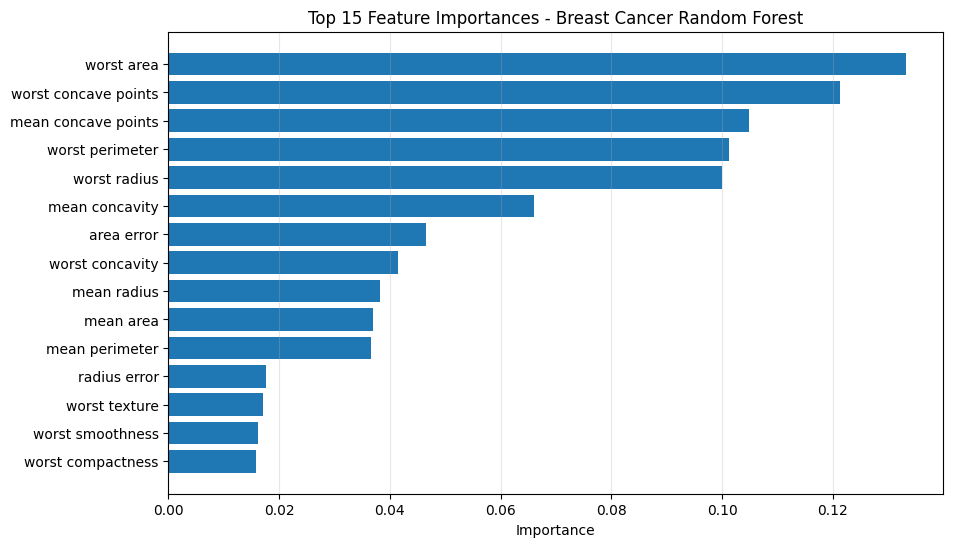

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(cancer_importance_df["feature"][::-1], cancer_importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Breast Cancer Random Forest")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Decision Tree | Model yang membagi data berdasarkan nilai fitur |
| Root Node | Node awal berisi seluruh data |
| Leaf Node | Node akhir yang menghasilkan prediksi |
| Gini Impurity | Ukuran ketidakmurnian kelas dalam node |
| Entropy | Ukuran ketidakpastian informasi |
| Information Gain | Penurunan impurity setelah split |
| Overfitting | Model terlalu mengikuti data training |
| Bagging | Ensemble berbasis bootstrap sampling |
| Random Forest | Banyak decision tree dengan feature randomness |
| Feature Importance | Ukuran kontribusi fitur terhadap prediksi |
| Boosting | Model dibangun berurutan untuk memperbaiki error |
| Learning Rate | Besar kontribusi setiap model baru pada boosting |
| Grid Search | Mencoba kombinasi hyperparameter secara sistematis |
| Randomized Search | Tuning parameter dengan sampling acak |
| Stacking | Menggabungkan beberapa model dengan meta-model |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa tree-based algorithms adalah pendekatan machine learning yang intuitif, kuat, dan mudah divisualisasikan. Decision Tree bekerja dengan membagi data berdasarkan fitur untuk meningkatkan kemurnian node. Namun, pohon tunggal cenderung mudah overfitting jika kompleksitasnya tidak dibatasi.

Ensemble methods seperti Random Forest dan Gradient Boosting digunakan untuk meningkatkan performa dan stabilitas model. Random Forest menggunakan bagging untuk mengurangi variance, sedangkan Gradient Boosting membangun model secara berurutan untuk memperbaiki error dari model sebelumnya. Stacking menggabungkan beberapa model dan menggunakan meta-model untuk menghasilkan prediksi akhir.

Poin penting dari chapter ini:

- Decision Tree mudah dipahami dan dapat divisualisasikan.
- Gini impurity dan entropy digunakan untuk menentukan split.
- Hyperparameter seperti `max_depth` dan `min_samples_leaf` penting untuk mengontrol overfitting.
- Random Forest menggabungkan banyak tree untuk meningkatkan stabilitas.
- Feature importance membantu interpretasi model.
- Gradient Boosting membangun model secara bertahap untuk memperbaiki error.
- Learning rate dan jumlah estimator sangat memengaruhi Gradient Boosting.
- GridSearchCV dan RandomizedSearchCV dapat digunakan untuk tuning hyperparameter.
- Ensemble methods biasanya lebih kuat dibanding decision tree tunggal, terutama pada data kompleks.

Secara keseluruhan, tree-based algorithms dan ensemble methods merupakan salah satu kelompok model paling penting dalam machine learning karena kuat, fleksibel, dan relatif mudah digunakan pada berbagai jenis dataset.